In [1]:
# imports
import snntorch as snn
from snntorch import spikeplot as splt
from snntorch import spikegen
from snntorch.functional import probe

import eleanor.models.torch as models

import torch
import torch.nn as nn

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
Ps = 0.25
dt = 1e-3
Idsc = 30e-12
threshold = 2.5  # For histerisis
model = nn.Sequential(
    models.Bruno(
        I_dsc=Idsc,
        threshold=threshold,
        dt=dt,
        paramsScale=1e10,
        P_s=Ps,
        variability=0.1,
        nsteps=10,
    )
)

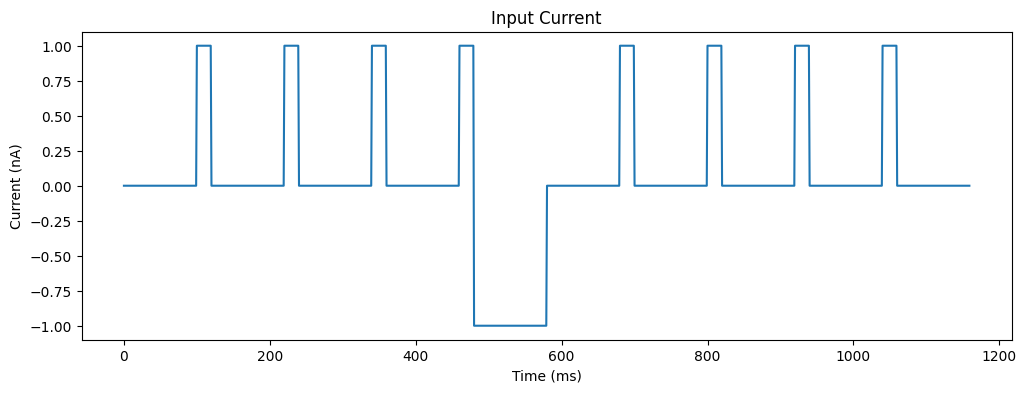

In [3]:
N = 50
AMPLITUDE = 1
input_1 = torch.concatenate(
    [torch.zeros(N, 100), torch.zeros(N, 20) + AMPLITUDE], dim=1
)
input_1 = [input_1 for _ in range(4)]

input_2 = torch.concatenate(
    [torch.zeros(N, 100) - AMPLITUDE, torch.zeros(N, 100)], dim=1
)

input_3 = torch.concatenate(
    [torch.zeros(N, 20) + AMPLITUDE, torch.zeros(N, 100)], dim=1
)
input_3 = [input_3 for _ in range(4)]

input = torch.cat(input_1 + [input_2] + input_3, dim=1)

plt.figure(figsize=(12, 4))
plt.plot(input[0])
plt.title("Input Current")
plt.xlabel("Time (ms)")
plt.ylabel("Current (nA)")
plt.show()

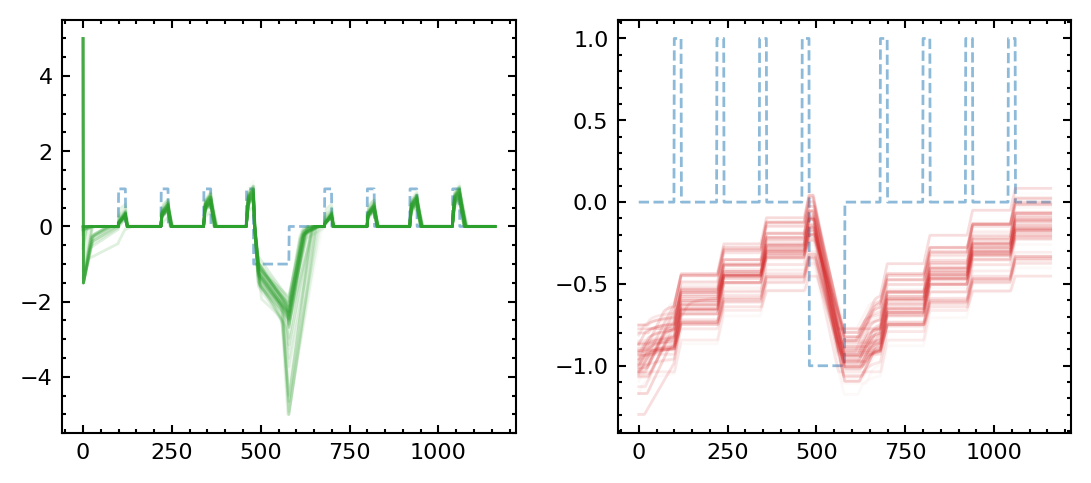

In [4]:
from matplotlib.collections import LineCollection

mem_monitor = probe.AttributeMonitor("mem", False, model, instance=models.Bruno)
pol_monitor = probe.AttributeMonitor("pol", False, model, instance=models.Bruno)

for t in range(input.shape[1]):
    model(input[:, t])

alphas = np.linspace(0.01, 0.2, N)

with mpl.style.context("boilerplot.ieeetran"):
    fig, ax = plt.subplots(1, 2, figsize=(5.45, 2.3), dpi=200)
    ax[0].plot(input[0] / AMPLITUDE, "--", alpha=0.5)
    # ax[0].plot(torch.stack(mem_monitor['0']), 'tab:blue')
    for line, alpha in zip(torch.stack(mem_monitor["0"]).T, alphas):
        ax[0].plot(line, color="tab:green", alpha=alpha)

    ax[1].plot(input[0] / AMPLITUDE, "--", alpha=0.5)
    for line, alpha in zip(torch.stack(pol_monitor["0"]).T, alphas):
        ax[1].plot(line / model[0].P_s, color="tab:red", alpha=alpha)
    plt.show()